# Task 9 Three-Stage Workflow

This notebook follows Task 8 and Task 9 together: Task 8 Stage 1 predicts coefficient vectors from gradient data, Task 9 general MLP reconstructs masks from those coefficient vectors, and an optional two-circle specialist acts as a third-stage override for `two_circles` samples. The Task 9 path uses BCE mask training with PDF-aligned rectangle edge weighting, rectangle-focused sample duplication, validation-selected thresholding, real held-out test data, and reconstruction graphs.

## Imports and Project Path

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

root = Path.cwd()
while root != root.parent and not (root / 'src').exists():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from config import (
    Stage1ModelConfig,
    StageTrainingConfig,
    Task9GeneralMLPConfig,
    Task9RunConfig,
    Task9SpecialistMLPConfig,
    Task9StackConfig,
)
from models import Stage1Regressor, binary_iou, evaluate_regression_predictions, evaluate_stage2_predictions, fit_stage1_model, predict_stage1_coefficients, select_best_stage2_threshold, set_torch_seed
from models.stage2.train import predict_stage2_logits
from models.task9 import Task9CombinedModel, Task9GeneralMaskMLP, Task9TwoCircleSpecialistMLP, predict_task9_combined_logits, train_task9_head
from workflows.task9 import build_task9_general_dataset, build_task9_specialist_dataset
from workflows.task9.datasets import augment_task9_feature_rows, augment_task9_general_training_split

np.random.seed(42)
set_torch_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Task 9 Run Config

These settings keep the run large enough to be meaningful while still being practical for iterative experimentation. The specialist is enabled because `N >= 4`.

In [2]:
run_config = Task9RunConfig(
    N=10,
    training_samples=10000,
    validation_samples=2000,
    specialist_training_samples=4000,
    specialist_validation_samples=1000,
    test_samples=2000,
    grid_size=32,
    threshold=0.5,
    use_validation_threshold_sweep=True,
    threshold_candidates=(0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9),
    noise_level=0.01,
    output_dir=Path('outputs/task9_notebook'),
    model=Task9StackConfig(
        # Task 8 Stage 1: 128-256-128 DNN, dropout 0.2, MSE, lr 0.0005.
        stage1=Stage1ModelConfig(),
        general=Task9GeneralMLPConfig(
            use_rectangle_edge_weighting=True,
            rectangle_edge_weight=3.0,
            rectangle_edge_width=2,
            edge_weight_mode='rectangle',
            enable_rectangle_edge_augmentation=True,
            rectangle_augmentation_copies=2,
        ),
        specialist=Task9SpecialistMLPConfig(),
    ),
)
run_config


Task9RunConfig(N=10, training_samples=10000, validation_samples=2000, test_samples=2000, specialist_training_samples=4000, specialist_validation_samples=1000, rho=0.8, grid_size=32, threshold=0.5, use_validation_threshold_sweep=True, threshold_candidates=(0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9), noise_level=0.01, seed=42, model=Task9StackConfig(stage1=Stage1ModelConfig(hidden_layer_sizes=(128, 256, 128), dropout_rates=(0.2, 0.2, 0.2), training=StageTrainingConfig(epochs=200, batch_size=32, learning_rate=0.0005, validation_frequency=10, verbose=True, early_stopping_patience=10, min_epochs=None, min_improvement=None, lr_drop_factor=None, lr_drop_period=None, weight_decay=0.0, gradient_clip_norm=None, loss_type='bce', dice_loss_weight=0.0, dice_smooth=1.0)), general=Task9GeneralMLPConfig(hidden_layer_sizes=(512, 1024, 2048), dropout_rates=(0.2, 0.2, 0.2), use_rectangle_edge_weighting=True, rectangle_edge_weight=3.0, rectangle_edge_width=2, edge_weight_mode='

In [3]:
print('N:', run_config.N)
print('Train / validation / test:', run_config.training_samples, run_config.validation_samples, run_config.test_samples)
print('Specialist train / validation:', run_config.effective_specialist_training_samples, run_config.effective_specialist_validation_samples)
print('Grid size:', run_config.grid_size)
print('Threshold:', run_config.threshold)
print('Stage 1 layers:', run_config.model.stage1.hidden_layer_sizes)
print('General Task 9 layers:', run_config.model.general.hidden_layer_sizes)
print('Specialist Task 9 layers:', run_config.model.specialist.hidden_layer_sizes)
print('Specialist enabled:', run_config.specialist_enabled)

N: 10
Train / validation / test: 10000 2000 2000
Specialist train / validation: 4000 1000
Grid size: 32
Threshold: 0.5
Stage 1 layers: (128, 256, 128)
General Task 9 layers: (512, 1024, 2048)
Specialist Task 9 layers: (1024, 2048, 4096)
Specialist enabled: True


## Build General and Specialist Datasets

The general Task 9 model uses the normal mixed-shape dataset. The specialist now uses a dedicated two-circle dataset with explicit regimes: separated, touching, overlapping, and nested.

In [4]:
general_dataset = build_task9_general_dataset(run_config)
specialist_dataset = build_task9_specialist_dataset(run_config) if run_config.specialist_enabled else None

print('General train gradient data shape:', general_dataset.train.gradient_data.shape)
print('General train coefficients shape:', general_dataset.train.coefficients.shape)
print('General train masks shape:', general_dataset.train.masks.shape)
print('General fixed benchmark examples:', len(general_dataset.fixed.names))
if specialist_dataset is not None:
    print('Specialist train gradient data shape:', specialist_dataset.train.gradient_data.shape)
    print('Specialist-only shape types:', sorted(set(specialist_dataset.train.shape_types)))

General train gradient data shape: (10000, 22)
General train coefficients shape: (10000, 22)
General train masks shape: (10000, 1024)
General fixed benchmark examples: 5
Specialist train gradient data shape: (4000, 22)
Specialist-only shape types: ['two_circles']


## Notebook Helper Functions

These helpers keep the rest of the notebook focused on model behavior instead of plotting boilerplate.

In [5]:
def sigmoid(logits):
    return 1.0 / (1.0 + np.exp(-logits))

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

def compute_sample_ious(y_true, logits, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    return np.array([binary_iou(true_row, pred_row) for true_row, pred_row in zip(y_true, binary_predictions, strict=False)])

def compute_sample_pixel_accuracy(y_true, logits, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    return np.mean(binary_predictions == y_true, axis=1)

def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(1, len(history['train_loss']) + 1), history['train_loss'], marker='o')
    axes[0].set_title(f'{title_prefix} Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['validation_steps'], history['val_loss'], marker='o', color='tab:orange')
    axes[1].set_title(f'{title_prefix} Validation Loss')
    axes[1].set_xlabel('Validation step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_shape_type_breakdown(shape_types, values, title, ylabel):
    frame = pd.DataFrame({'shape_type': shape_types, 'value': values})
    grouped = frame.groupby('shape_type', as_index=False)['value'].mean().sort_values('value')
    plt.figure(figsize=(8, 4))
    plt.barh(grouped['shape_type'], grouped['value'])
    plt.title(title)
    plt.xlabel(ylabel)
    plt.grid(True, axis='x', alpha=0.3)
    plt.show()

def plot_threshold_sweep(y_true, logits, thresholds):
    rows = []
    for threshold in thresholds:
        metrics = evaluate_stage2_predictions(y_true, logits, threshold)
        rows.append({'threshold': threshold, 'mean_iou': metrics['mean_iou'], 'pixel_accuracy': metrics['pixel_accuracy']})
    frame = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(frame['threshold'], frame['mean_iou'], marker='o')
    axes[0].set_title('Mean IoU vs Threshold')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Mean IoU')
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(frame['threshold'], frame['pixel_accuracy'], marker='o', color='tab:orange')
    axes[1].set_title('Pixel Accuracy vs Threshold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Pixel Accuracy')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return frame

def show_reconstruction_rows(true_masks, logits, names, grid_size, threshold, row_indices, title):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    fig, axes = plt.subplots(len(row_indices), 4, figsize=(12, 3 * len(row_indices)))
    if len(row_indices) == 1:
        axes = np.array([axes])
    for plot_row, sample_index in enumerate(row_indices):
        true_mask = true_masks[sample_index].reshape(grid_size, grid_size)
        probability_mask = probabilities[sample_index].reshape(grid_size, grid_size)
        predicted_mask = binary_predictions[sample_index].reshape(grid_size, grid_size)
        error_overlay = predicted_mask - true_mask

        axes[plot_row, 0].imshow(true_mask, cmap='gray', origin='lower')
        axes[plot_row, 0].set_title(f'True: {names[sample_index]}')
        axes[plot_row, 0].axis('off')

        axes[plot_row, 1].imshow(probability_mask, cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
        axes[plot_row, 1].set_title('Predicted probability')
        axes[plot_row, 1].axis('off')

        axes[plot_row, 2].imshow(predicted_mask, cmap='gray', origin='lower')
        axes[plot_row, 2].set_title('Thresholded prediction')
        axes[plot_row, 2].axis('off')

        axes[plot_row, 3].imshow(error_overlay, cmap='bwr', origin='lower', vmin=-1.0, vmax=1.0)
        axes[plot_row, 3].set_title('Error overlay')
        axes[plot_row, 3].axis('off')

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

def show_simple_mask_pairs(true_masks, predicted_masks, names, grid_size, row_indices, title, score_values=None, score_label='IoU'):
    fig, axes = plt.subplots(len(row_indices), 2, figsize=(6, 3 * len(row_indices)))
    if len(row_indices) == 1:
        axes = np.array([axes])
    for plot_row, sample_index in enumerate(row_indices):
        axes[plot_row, 0].imshow(true_masks[sample_index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        axes[plot_row, 0].set_title(f'True: {names[sample_index]}')
        axes[plot_row, 0].axis('off')

        axes[plot_row, 1].imshow(predicted_masks[sample_index].reshape(grid_size, grid_size), cmap='gray', origin='lower')
        if score_values is None:
            axes[plot_row, 1].set_title('Predicted')
        else:
            axes[plot_row, 1].set_title(f'Predicted\n{score_label}={score_values[sample_index]:.3f}')
        axes[plot_row, 1].axis('off')

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

def show_average_maps_by_shape_type(shape_types, true_masks, logits, grid_size, threshold):
    probabilities = sigmoid(logits)
    binary_predictions = (probabilities >= threshold).astype(np.float32)
    unique_shape_types = sorted(set(shape_types))
    fig, axes = plt.subplots(len(unique_shape_types), 3, figsize=(9, 3 * len(unique_shape_types)))
    if len(unique_shape_types) == 1:
        axes = np.array([axes])
    for row_index, shape_type in enumerate(unique_shape_types):
        type_indices = [index for index, current_type in enumerate(shape_types) if current_type == shape_type]
        mean_true = true_masks[type_indices].mean(axis=0).reshape(grid_size, grid_size)
        mean_probability = probabilities[type_indices].mean(axis=0).reshape(grid_size, grid_size)
        mean_error = np.abs(binary_predictions[type_indices] - true_masks[type_indices]).mean(axis=0).reshape(grid_size, grid_size)

        axes[row_index, 0].imshow(mean_true, cmap='gray', origin='lower')
        axes[row_index, 0].set_title(f'{shape_type}: mean true mask')
        axes[row_index, 0].axis('off')

        axes[row_index, 1].imshow(mean_probability, cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
        axes[row_index, 1].set_title('Mean predicted probability')
        axes[row_index, 1].axis('off')

        axes[row_index, 2].imshow(mean_error, cmap='magma', origin='lower', vmin=0.0, vmax=1.0)
        axes[row_index, 2].set_title('Mean absolute mask error')
        axes[row_index, 2].axis('off')

    plt.tight_layout()
    plt.show()

## Stage 1 Setup and Training

Task 9 still begins with the shared Stage 1 DNN. Its job is to turn gradient data into coefficient vectors that stay as vectors for the mask MLPs. Those coefficient vectors are never reshaped into images before the MLP heads.

In [6]:
stage1_model = Stage1Regressor(
    input_dim=run_config.gradient_feature_size,
    output_dim=run_config.coefficient_size,
    hidden_dims=run_config.model.stage1.hidden_layer_sizes,
    dropout_rates=run_config.model.stage1.dropout_rates,
)
print(stage1_model)
print('Stage 1 parameter count:', count_parameters(stage1_model))
stage1_result = fit_stage1_model(
    model=stage1_model,
    train_features=general_dataset.train.gradient_data,
    train_targets=general_dataset.train.coefficients,
    val_features=general_dataset.validation.gradient_data,
    val_targets=general_dataset.validation.coefficients,
    epochs=run_config.model.stage1.training.epochs,
    batch_size=run_config.model.stage1.training.batch_size,
    learning_rate=run_config.model.stage1.training.learning_rate,
    device=device,
    validation_frequency=run_config.model.stage1.training.validation_frequency,
    verbose=run_config.model.stage1.training.verbose,
    early_stopping_patience=run_config.model.stage1.training.early_stopping_patience,
)

Stage1Regressor(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=22, bias=True)
  )
)
Stage 1 parameter count: 71702
Epoch 1/200 | step 10 | train_loss=0.936924 | val_loss=0.892142
Epoch 1/200 | step 20 | train_loss=0.998611 | val_loss=0.852649
Epoch 1/200 | step 30 | train_loss=0.932675 | val_loss=0.808336
Epoch 1/200 | step 40 | train_loss=0.873210 | val_loss=0.762079
Epoch 1/200 | step 50 | train_loss=0.875622 | val_loss=0.704604
Epoch 1/200 | step 60 | train_loss=0.848996 | val_loss=0.658514
Epoch 1/200 | step 70 | train_loss=0.844114 | val_loss=0.609205
Epoch 1/200 | step 80 | train_loss=0.815445 | val_loss=0.56365

## Stage 1 Diagnostics

Stage 1 test metrics: {'mse': 2.2722260837326758e-06, 'mae': 0.0007107077981345356}
Stage 1 fixed metrics: {'mse': 1.148707042375463e-06, 'mae': 0.00042478038812987506}


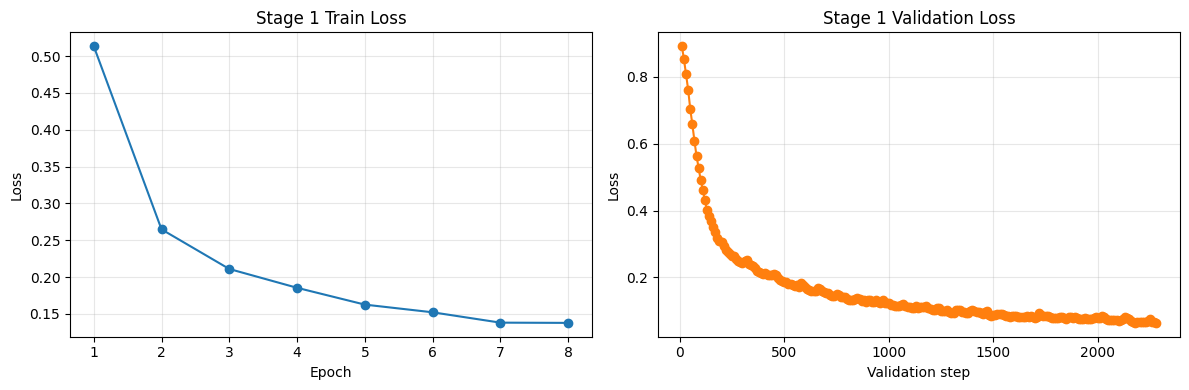

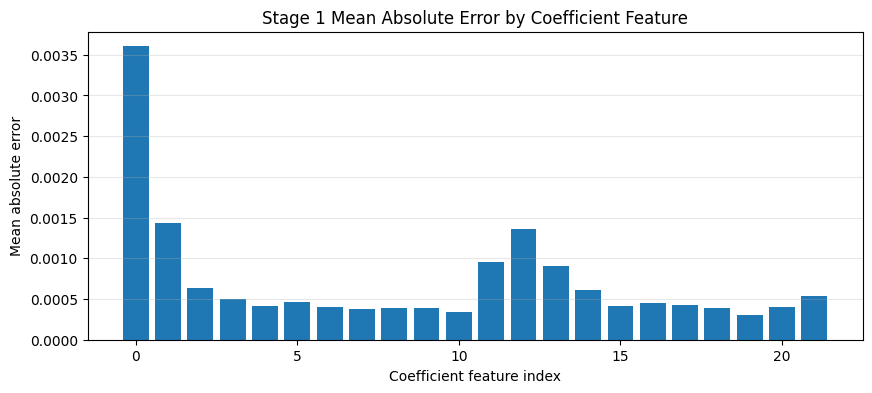

In [7]:
predicted_train_coefficients = predict_stage1_coefficients(stage1_model, general_dataset.train.gradient_data, device=device, training_result=stage1_result)
predicted_validation_coefficients = predict_stage1_coefficients(stage1_model, general_dataset.validation.gradient_data, device=device, training_result=stage1_result)
predicted_test_coefficients = predict_stage1_coefficients(stage1_model, general_dataset.test.gradient_data, device=device, training_result=stage1_result)
predicted_fixed_coefficients = predict_stage1_coefficients(stage1_model, general_dataset.fixed.gradient_data, device=device, training_result=stage1_result)

stage1_test_metrics = evaluate_regression_predictions(general_dataset.test.coefficients, predicted_test_coefficients)
stage1_fixed_metrics = evaluate_regression_predictions(general_dataset.fixed.coefficients, predicted_fixed_coefficients)
print('Stage 1 test metrics:', stage1_test_metrics)
print('Stage 1 fixed metrics:', stage1_fixed_metrics)
plot_history(stage1_result.history, 'Stage 1')

coefficient_errors = np.abs(predicted_validation_coefficients - general_dataset.validation.coefficients)
mean_coefficient_errors = coefficient_errors.mean(axis=0)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(mean_coefficient_errors)), mean_coefficient_errors)
plt.title('Stage 1 Mean Absolute Error by Coefficient Feature')
plt.xlabel('Coefficient feature index')
plt.ylabel('Mean absolute error')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Task 9 General MLP

This is the general mask model. It takes the Stage 1 predicted coefficient vectors directly as vectors and predicts flattened mask vectors. The Task 9 path duplicates rectangle samples and applies rectangle edge weighting to emphasize sharp-edge reconstruction.

Rectangle augmentation added rows: 4976
Epoch 1/150 | step 30 | train_loss=1.072763 | val_loss=0.529246 | lr=0.001000
Epoch 1/150 | step 60 | train_loss=0.847069 | val_loss=0.432486 | lr=0.001000
Epoch 1/150 | step 90 | train_loss=0.747091 | val_loss=0.415061 | lr=0.001000
Epoch 1/150 | step 120 | train_loss=0.691060 | val_loss=0.393810 | lr=0.001000
Epoch 1/150 | step 150 | train_loss=0.654254 | val_loss=0.385771 | lr=0.001000
Epoch 1/150 | step 180 | train_loss=0.626197 | val_loss=0.377420 | lr=0.001000
Epoch 1/150 | step 210 | train_loss=0.607427 | val_loss=0.371938 | lr=0.001000
Epoch 2/150 | step 240 | train_loss=0.478985 | val_loss=0.369885 | lr=0.001000
Epoch 2/150 | step 270 | train_loss=0.466624 | val_loss=0.364880 | lr=0.001000
Epoch 2/150 | step 300 | train_loss=0.470645 | val_loss=0.354675 | lr=0.001000
Epoch 2/150 | step 330 | train_loss=0.466339 | val_loss=0.357980 | lr=0.001000
Epoch 2/150 | step 360 | train_loss=0.464381 | val_loss=0.357565 | lr=0.001000
Epoch 2/150 | s

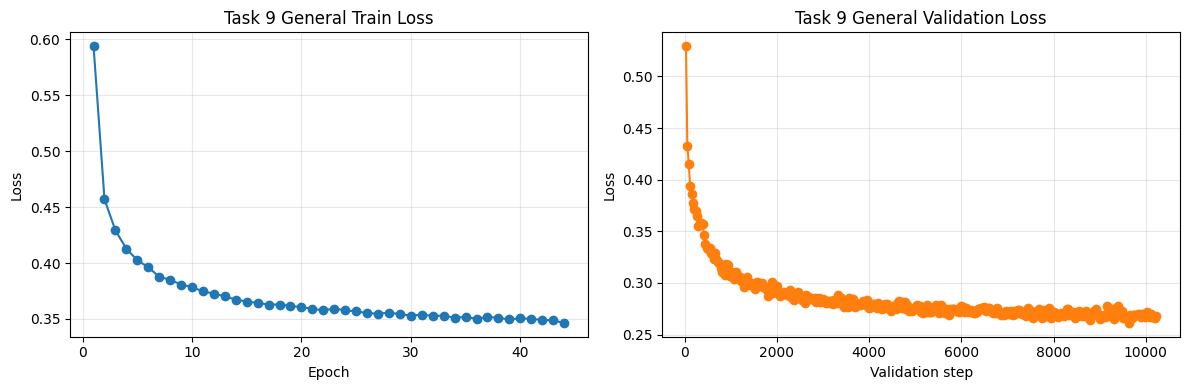

In [8]:
augmented_general_train = augment_task9_general_training_split(general_dataset.train, run_config.model.general)
augmented_predicted_train_coefficients = augment_task9_feature_rows(
    predicted_train_coefficients,
    general_dataset.train.shape_types,
    run_config.model.general,
)
rectangle_augmentation_added = augmented_general_train.masks.shape[0] - general_dataset.train.masks.shape[0]
print('Rectangle augmentation added rows:', rectangle_augmentation_added)

general_head = train_task9_head(
    name='task9_general',
    model=Task9GeneralMaskMLP(
        input_dim=run_config.coefficient_size,
        output_dim=run_config.mask_pixels,
        hidden_dims=run_config.model.general.hidden_layer_sizes,
        dropout_rates=run_config.model.general.dropout_rates,
    ),
    train_features=augmented_predicted_train_coefficients,
    train_targets=augmented_general_train.masks,
    val_features=predicted_validation_coefficients,
    val_targets=general_dataset.validation.masks,
    device=device,
    training_config=run_config.model.general.training,
    train_shape_types=augmented_general_train.shape_types,
    grid_size=run_config.grid_size,
    use_rectangle_edge_weighting=run_config.model.general.use_rectangle_edge_weighting,
    rectangle_edge_weight=run_config.model.general.rectangle_edge_weight,
    rectangle_edge_width=run_config.model.general.rectangle_edge_width,
    edge_weight_mode=run_config.model.general.edge_weight_mode,
)
print('General MLP parameter count:', count_parameters(general_head.model))
plot_history(general_head.training_result.history, 'Task 9 General')


## Task 9 Specialist Two-Circle MLP

For `N >= 4`, Task 9 adds a specialist just for `two_circles`. This notebook uses the dedicated two-circle regime generator as the specialist training source.

Epoch 1/200 | step 30 | train_loss=0.763127 | val_loss=0.486247 | lr=0.000500
Epoch 1/200 | step 60 | train_loss=0.594447 | val_loss=0.374681 | lr=0.000500
Epoch 1/200 | step 90 | train_loss=0.515677 | val_loss=0.349107 | lr=0.000500
Epoch 1/200 | step 120 | train_loss=0.474089 | val_loss=0.331093 | lr=0.000500
Epoch 2/200 | step 150 | train_loss=0.329738 | val_loss=0.315857 | lr=0.000500
Epoch 2/200 | step 180 | train_loss=0.320525 | val_loss=0.306330 | lr=0.000500
Epoch 2/200 | step 210 | train_loss=0.317149 | val_loss=0.298607 | lr=0.000500
Epoch 2/200 | step 240 | train_loss=0.314478 | val_loss=0.298913 | lr=0.000500
Epoch 3/200 | step 270 | train_loss=0.289593 | val_loss=0.287558 | lr=0.000500
Epoch 3/200 | step 300 | train_loss=0.288612 | val_loss=0.281554 | lr=0.000500
Epoch 3/200 | step 330 | train_loss=0.288443 | val_loss=0.282751 | lr=0.000500
Epoch 3/200 | step 360 | train_loss=0.288258 | val_loss=0.272245 | lr=0.000500
Epoch 4/200 | step 390 | train_loss=0.272731 | val_loss

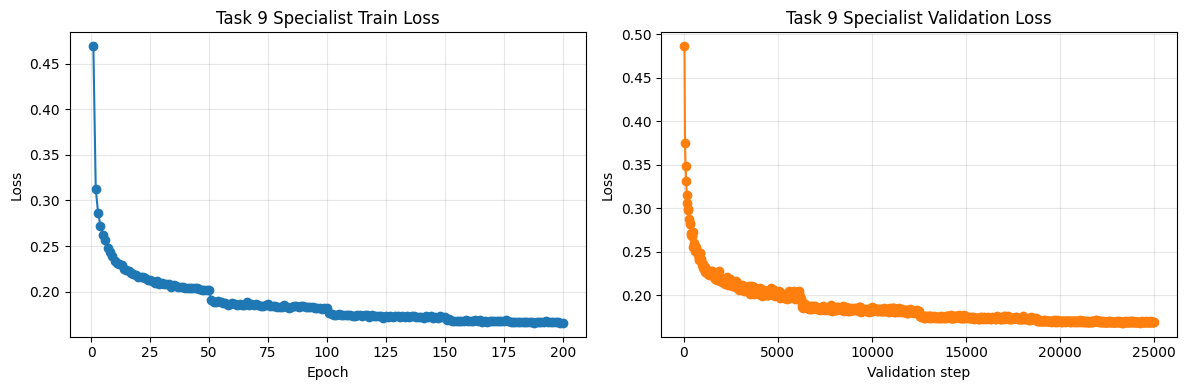

In [9]:
specialist_head = None
if run_config.specialist_enabled and specialist_dataset is not None:
    predicted_specialist_train_coefficients = predict_stage1_coefficients(stage1_model, specialist_dataset.train.gradient_data, device=device, training_result=stage1_result)
    predicted_specialist_validation_coefficients = predict_stage1_coefficients(stage1_model, specialist_dataset.validation.gradient_data, device=device, training_result=stage1_result)
    specialist_head = train_task9_head(
        name='task9_specialist',
        model=Task9TwoCircleSpecialistMLP(
            input_dim=run_config.coefficient_size,
            output_dim=run_config.mask_pixels,
            hidden_dims=run_config.model.specialist.hidden_layer_sizes,
            dropout_rates=run_config.model.specialist.dropout_rates,
        ),
        train_features=predicted_specialist_train_coefficients,
        train_targets=specialist_dataset.train.masks,
        val_features=predicted_specialist_validation_coefficients,
        val_targets=specialist_dataset.validation.masks,
        device=device,
        training_config=run_config.model.specialist.training,
    )
    print('Specialist MLP parameter count:', count_parameters(specialist_head.model))
    plot_history(specialist_head.training_result.history, 'Task 9 Specialist')
else:
    print('Specialist is disabled for this run.')

## Combined Routing Logic

The combined model routes `two_circles` samples to the specialist when specialist routing is enabled. Everything else uses the general model.

In [10]:
combined_model = Task9CombinedModel(
    general=general_head,
    specialist=specialist_head,
    specialist_shape_type=run_config.model.specialist_shape_type,
    routing_mode=run_config.model.routing_mode,
)
combined_model

Task9CombinedModel(general=Task9TrainedHead(name='task9_general', model=Task9GeneralMaskMLP(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=2048, out_features=1024, bias=True)
  )
), training_result=ModelTrainingResult(history={'train_loss': [0.594015182975011, 0.4569958927284958, 0.4291726509984742, 0.41275060495250243, 0.4026098164737734, 0.39619864790867537, 0.38776001881839883, 0.3850245406994453, 0.3807971609963311, 0.3785232524586539, 0.37458407560474855, 0.37273164730296177, 0.370173062906306, 0.3672649738116142, 0.36556839127825874, 0.3643703647913077, 0.36288687523104185, 0.36287115565222555, 0.36169286938304573, 0.360564943

## Held-Out Test Evaluation

This is the real test of Task 9. The general and combined models are both evaluated on held-out test data, not just fixed examples.

In [11]:
general_validation_logits = predict_stage2_logits(general_head.model, predicted_validation_coefficients, device=device, training_result=general_head.training_result)
general_test_logits = predict_stage2_logits(general_head.model, predicted_test_coefficients, device=device, training_result=general_head.training_result)
general_fixed_logits = predict_stage2_logits(general_head.model, predicted_fixed_coefficients, device=device, training_result=general_head.training_result)
general_test_true_coeff_logits = predict_stage2_logits(general_head.model, general_dataset.test.coefficients, device=device, training_result=general_head.training_result)
general_fixed_true_coeff_logits = predict_stage2_logits(general_head.model, general_dataset.fixed.coefficients, device=device, training_result=general_head.training_result)

combined_validation_logits, validation_specialist_count = predict_task9_combined_logits(combined_model, predicted_validation_coefficients, general_dataset.validation.shape_types, device)
combined_test_logits, test_specialist_count = predict_task9_combined_logits(combined_model, predicted_test_coefficients, general_dataset.test.shape_types, device)
combined_fixed_logits, fixed_specialist_count = predict_task9_combined_logits(combined_model, predicted_fixed_coefficients, general_dataset.fixed.shape_types, device)
combined_test_true_coeff_logits, test_true_coeff_specialist_count = predict_task9_combined_logits(combined_model, general_dataset.test.coefficients, general_dataset.test.shape_types, device)
combined_fixed_true_coeff_logits, fixed_true_coeff_specialist_count = predict_task9_combined_logits(combined_model, general_dataset.fixed.coefficients, general_dataset.fixed.shape_types, device)

if run_config.use_validation_threshold_sweep:
    threshold_summary = select_best_stage2_threshold(
        general_dataset.validation.masks,
        combined_validation_logits,
        run_config.threshold_candidates,
    )
    selected_threshold = threshold_summary['selected_threshold']
else:
    selected_threshold = run_config.threshold
    threshold_summary = {
        'selected_threshold': selected_threshold,
        'selection_mode': 'fixed',
        'validation_metrics': evaluate_stage2_predictions(general_dataset.validation.masks, combined_validation_logits, selected_threshold),
    }

general_validation_metrics = evaluate_stage2_predictions(general_dataset.validation.masks, general_validation_logits, selected_threshold)
combined_validation_metrics = evaluate_stage2_predictions(general_dataset.validation.masks, combined_validation_logits, selected_threshold)
general_test_metrics = evaluate_stage2_predictions(general_dataset.test.masks, general_test_logits, selected_threshold)
combined_test_metrics = evaluate_stage2_predictions(general_dataset.test.masks, combined_test_logits, selected_threshold)
general_fixed_metrics = evaluate_stage2_predictions(general_dataset.fixed.masks, general_fixed_logits, selected_threshold)
combined_fixed_metrics = evaluate_stage2_predictions(general_dataset.fixed.masks, combined_fixed_logits, selected_threshold)

validation_two_circle_indices = np.array([
    index for index, shape_type in enumerate(general_dataset.validation.shape_types) if shape_type == run_config.model.specialist_shape_type
])
if validation_two_circle_indices.size:
    general_two_circle_validation_iou = compute_sample_ious(
        general_dataset.validation.masks[validation_two_circle_indices],
        general_validation_logits[validation_two_circle_indices],
        selected_threshold,
    ).mean()
    combined_two_circle_validation_iou = compute_sample_ious(
        general_dataset.validation.masks[validation_two_circle_indices],
        combined_validation_logits[validation_two_circle_indices],
        selected_threshold,
    ).mean()
else:
    general_two_circle_validation_iou = np.nan
    combined_two_circle_validation_iou = np.nan

print('Selected validation threshold:', selected_threshold)
print('Threshold validation metrics:', threshold_summary['validation_metrics'])
print('General validation metrics:', general_validation_metrics)
print('Combined validation metrics:', combined_validation_metrics)
print('General held-out test metrics:', general_test_metrics)
print('Combined held-out test metrics:', combined_test_metrics)
print('General fixed metrics:', general_fixed_metrics)
print('Combined fixed metrics:', combined_fixed_metrics)
print('Validation two-circle IoU, general:', general_two_circle_validation_iou)
print('Validation two-circle IoU, combined:', combined_two_circle_validation_iou)
print('Validation specialist samples:', validation_specialist_count)
print('Test specialist samples:', test_specialist_count)
print('Fixed specialist samples:', fixed_specialist_count)


Selected validation threshold: 0.8
Threshold validation metrics: {'mean_iou': 0.6294918506195797, 'pixel_accuracy': 0.9538398385047913}
General validation metrics: {'mean_iou': 0.6661296939107435, 'pixel_accuracy': 0.9566913843154907}
Combined validation metrics: {'mean_iou': 0.6294918506195797, 'pixel_accuracy': 0.9538398385047913}
General held-out test metrics: {'mean_iou': 0.6664637868423451, 'pixel_accuracy': 0.9577748775482178}
Combined held-out test metrics: {'mean_iou': 0.6264018903552164, 'pixel_accuracy': 0.9545620083808899}
General fixed metrics: {'mean_iou': 0.7600995474261745, 'pixel_accuracy': 0.954882800579071}
Combined fixed metrics: {'mean_iou': 0.7621950472544121, 'pixel_accuracy': 0.9566406011581421}
Validation two-circle IoU, general: 0.6257124637570848
Validation two-circle IoU, combined: 0.4967059732952404
Validation specialist samples: 568
Test specialist samples: 634
Fixed specialist samples: 1


In [12]:
comparison_table = pd.DataFrame([
    {
        'label': 'general',
        'test_mean_iou': general_test_metrics['mean_iou'],
        'test_pixel_accuracy': general_test_metrics['pixel_accuracy'],
        'fixed_mean_iou': general_fixed_metrics['mean_iou'],
        'fixed_pixel_accuracy': general_fixed_metrics['pixel_accuracy'],
        'parameter_count': count_parameters(general_head.model),
        'epochs_recorded': len(general_head.training_result.history['train_loss']),
    },
    {
        'label': 'combined',
        'test_mean_iou': combined_test_metrics['mean_iou'],
        'test_pixel_accuracy': combined_test_metrics['pixel_accuracy'],
        'fixed_mean_iou': combined_fixed_metrics['mean_iou'],
        'fixed_pixel_accuracy': combined_fixed_metrics['pixel_accuracy'],
        'parameter_count': count_parameters(general_head.model) + (count_parameters(specialist_head.model) if specialist_head is not None else 0),
        'epochs_recorded': len(general_head.training_result.history['train_loss']) + (len(specialist_head.training_result.history['train_loss']) if specialist_head is not None else 0),
    },
])
comparison_table

,label,test_mean_iou,test_pixel_accuracy,fixed_mean_iou,fixed_pixel_accuracy,parameter_count,epochs_recorded
0,general,0.666464,0.957775,0.760100,0.954883,4734464,44
1,combined,0.626402,0.954562,0.762195,0.956641,19445248,244


## Held-Out Test Reconstructions

These are real held-out test examples. This is the best place to judge how well Task 9 actually generalizes.

In [13]:
general_test_ious = compute_sample_ious(general_dataset.test.masks, general_test_logits, selected_threshold)
combined_test_ious = compute_sample_ious(general_dataset.test.masks, combined_test_logits, selected_threshold)
best_test_indices = np.argsort(combined_test_ious)[-3:][::-1]
worst_test_indices = np.argsort(combined_test_ious)[:3]
random_test_indices = np.random.default_rng(42).choice(len(general_dataset.test.names), size=3, replace=False)
print('Best combined test IoUs:', combined_test_ious[best_test_indices])
print('Worst combined test IoUs:', combined_test_ious[worst_test_indices])
print('Random test indices:', random_test_indices)

Best combined test IoUs: [0.94936709 0.94379391 0.93617021]
Worst combined test IoUs: [0. 0. 0.]
Random test indices: [1309  178 1547]


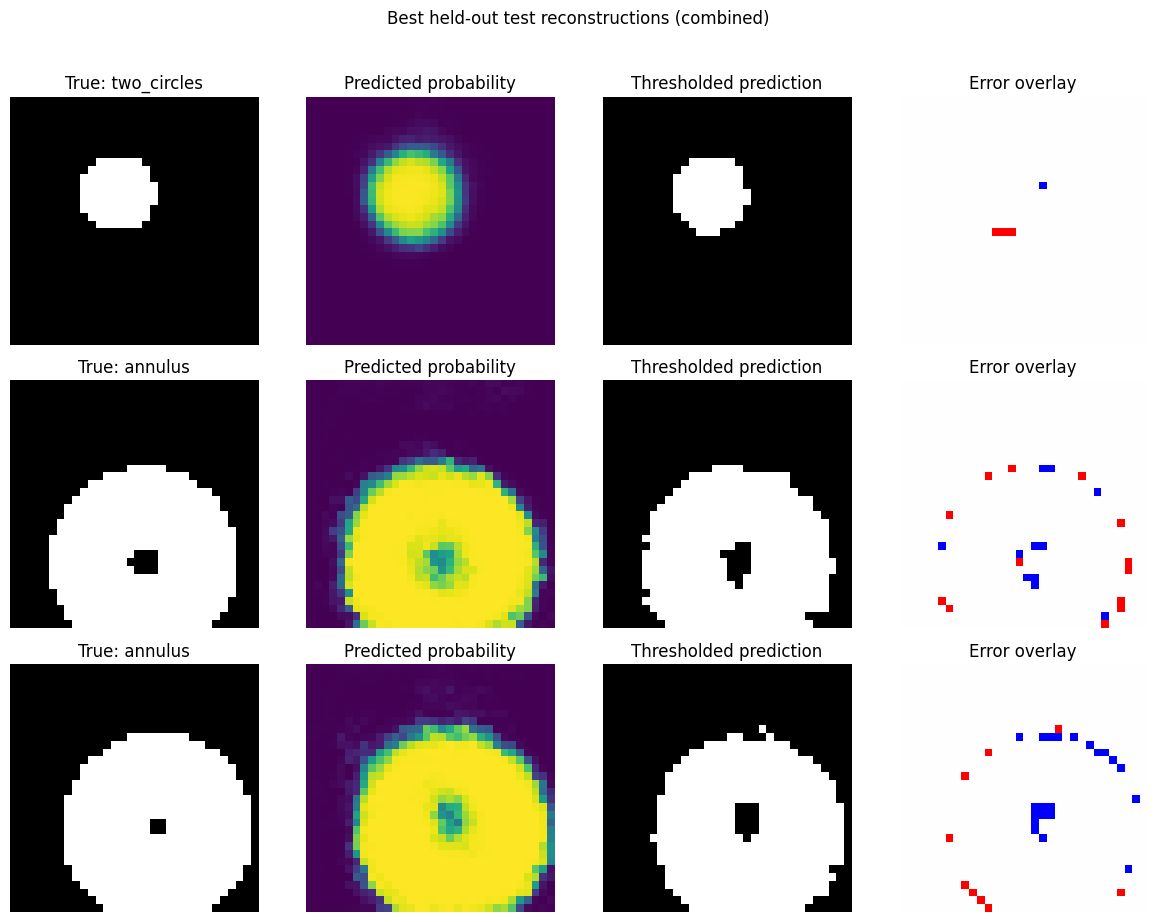

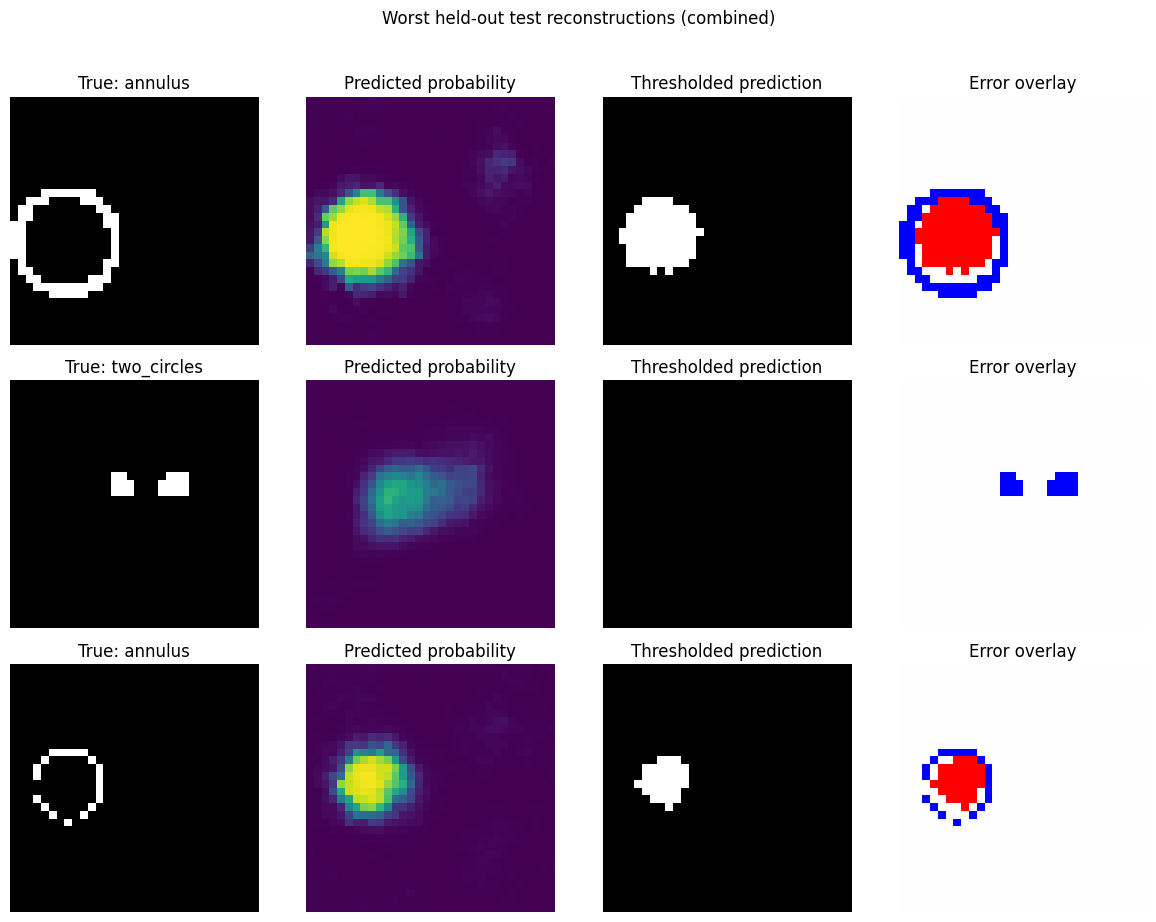

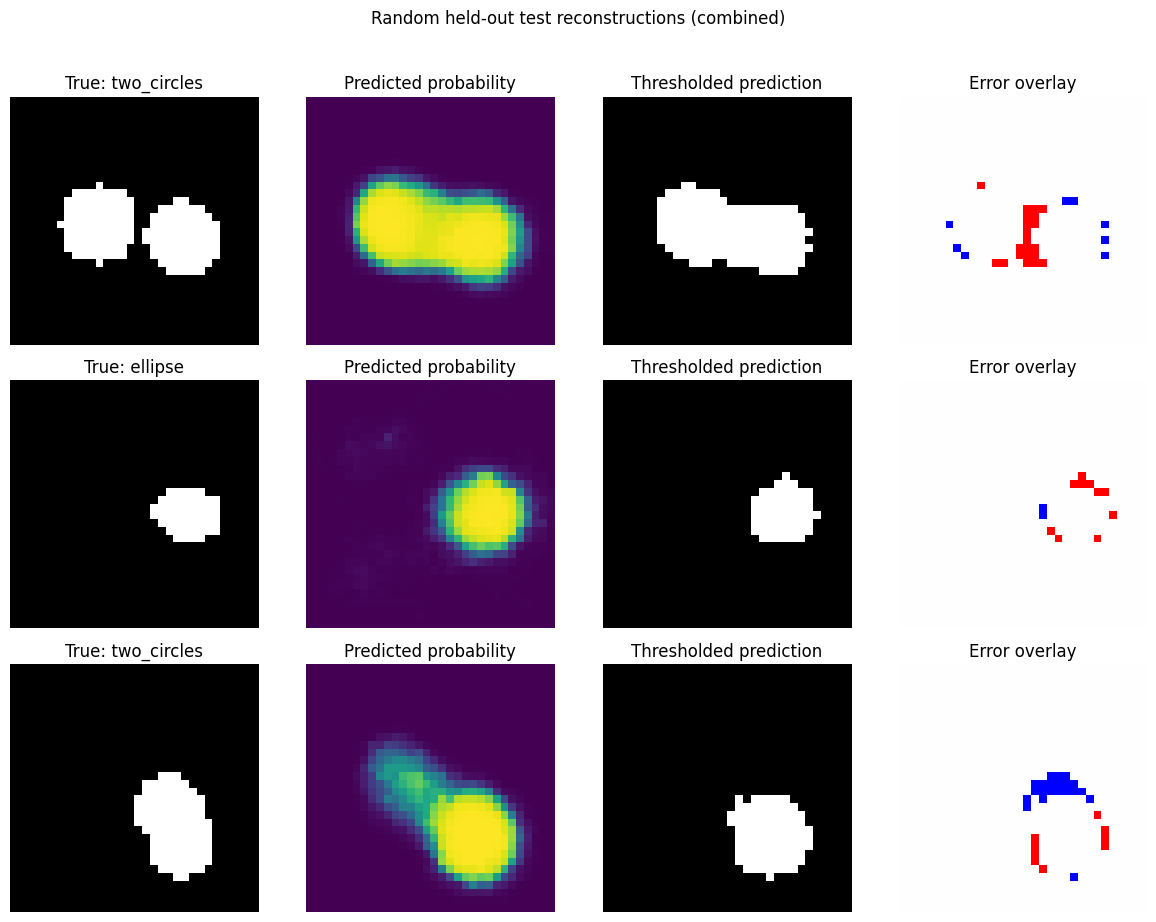

In [14]:
show_reconstruction_rows(general_dataset.test.masks, combined_test_logits, general_dataset.test.names, run_config.grid_size, selected_threshold, best_test_indices, 'Best held-out test reconstructions (combined)')
show_reconstruction_rows(general_dataset.test.masks, combined_test_logits, general_dataset.test.names, run_config.grid_size, selected_threshold, worst_test_indices, 'Worst held-out test reconstructions (combined)')
show_reconstruction_rows(general_dataset.test.masks, combined_test_logits, general_dataset.test.names, run_config.grid_size, selected_threshold, random_test_indices, 'Random held-out test reconstructions (combined)')

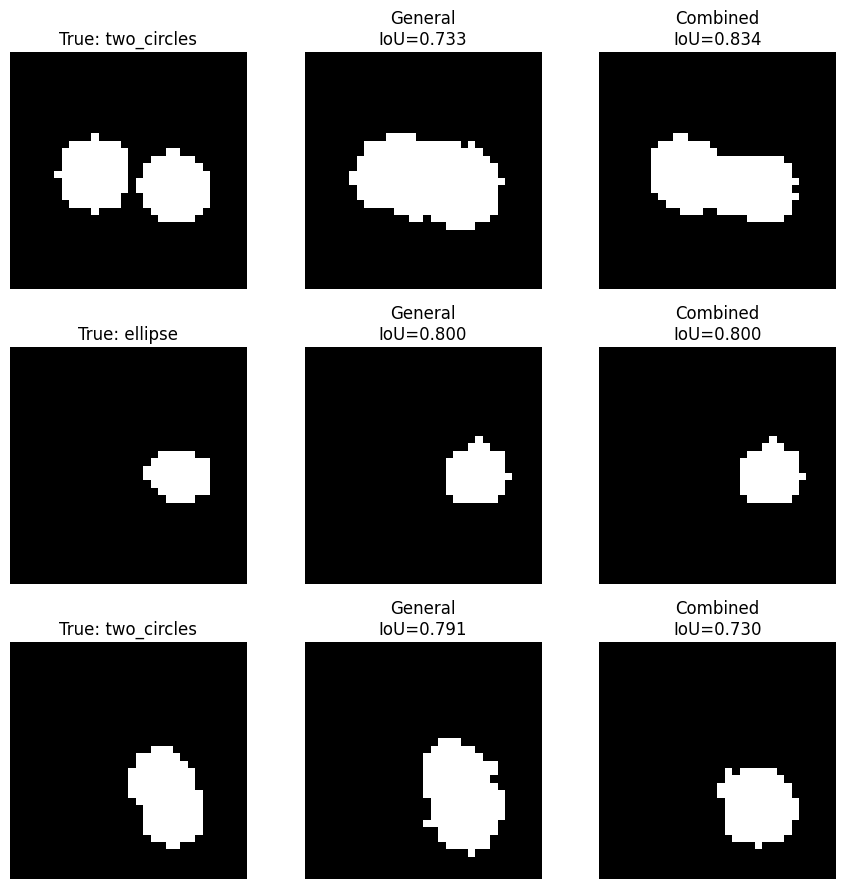

In [15]:
general_test_binary_masks = (sigmoid(general_test_logits) >= selected_threshold).astype(np.float32)
combined_test_binary_masks = (sigmoid(combined_test_logits) >= selected_threshold).astype(np.float32)
fig, axes = plt.subplots(len(random_test_indices), 3, figsize=(9, 3 * len(random_test_indices)))
if len(random_test_indices) == 1:
    axes = np.array([axes])
for row_index, sample_index in enumerate(random_test_indices):
    axes[row_index, 0].imshow(general_dataset.test.masks[sample_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 0].set_title(f'True: {general_dataset.test.names[sample_index]}')
    axes[row_index, 0].axis('off')
    axes[row_index, 1].imshow(general_test_binary_masks[sample_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 1].set_title(f'General\nIoU={general_test_ious[sample_index]:.3f}')
    axes[row_index, 1].axis('off')
    axes[row_index, 2].imshow(combined_test_binary_masks[sample_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 2].set_title(f'Combined\nIoU={combined_test_ious[sample_index]:.3f}')
    axes[row_index, 2].axis('off')
plt.tight_layout()
plt.show()

## Fixed Benchmark Reconstructions

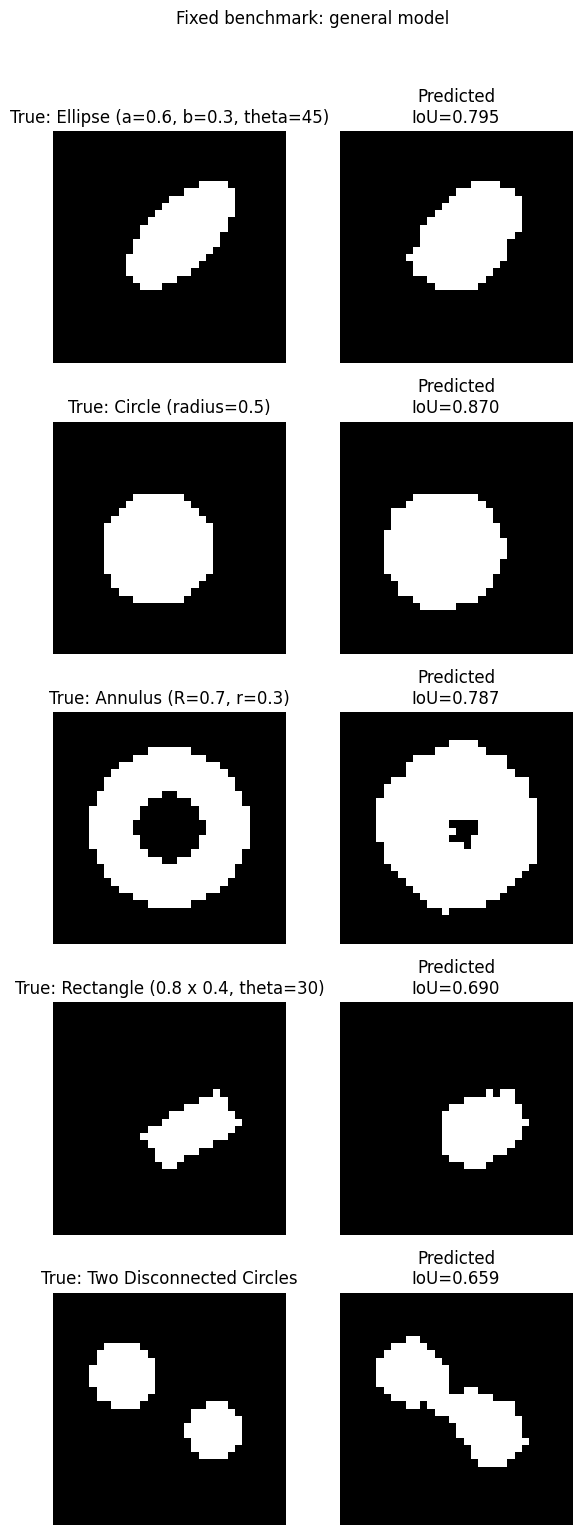

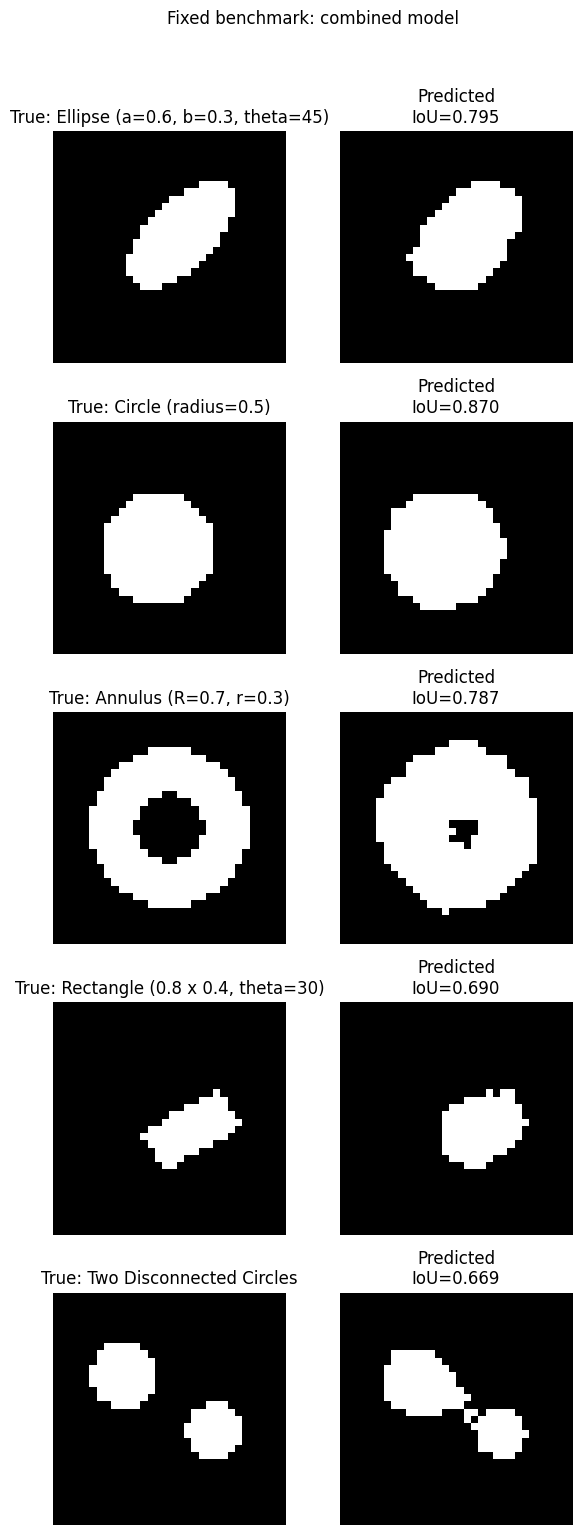

In [16]:
general_fixed_ious = compute_sample_ious(general_dataset.fixed.masks, general_fixed_logits, selected_threshold)
combined_fixed_ious = compute_sample_ious(general_dataset.fixed.masks, combined_fixed_logits, selected_threshold)
general_fixed_binary_masks = (sigmoid(general_fixed_logits) >= selected_threshold).astype(np.float32)
combined_fixed_binary_masks = (sigmoid(combined_fixed_logits) >= selected_threshold).astype(np.float32)

show_simple_mask_pairs(general_dataset.fixed.masks, general_fixed_binary_masks, general_dataset.fixed.names, run_config.grid_size, np.arange(len(general_dataset.fixed.names)), 'Fixed benchmark: general model', score_values=general_fixed_ious)
show_simple_mask_pairs(general_dataset.fixed.masks, combined_fixed_binary_masks, general_dataset.fixed.names, run_config.grid_size, np.arange(len(general_dataset.fixed.names)), 'Fixed benchmark: combined model', score_values=combined_fixed_ious)

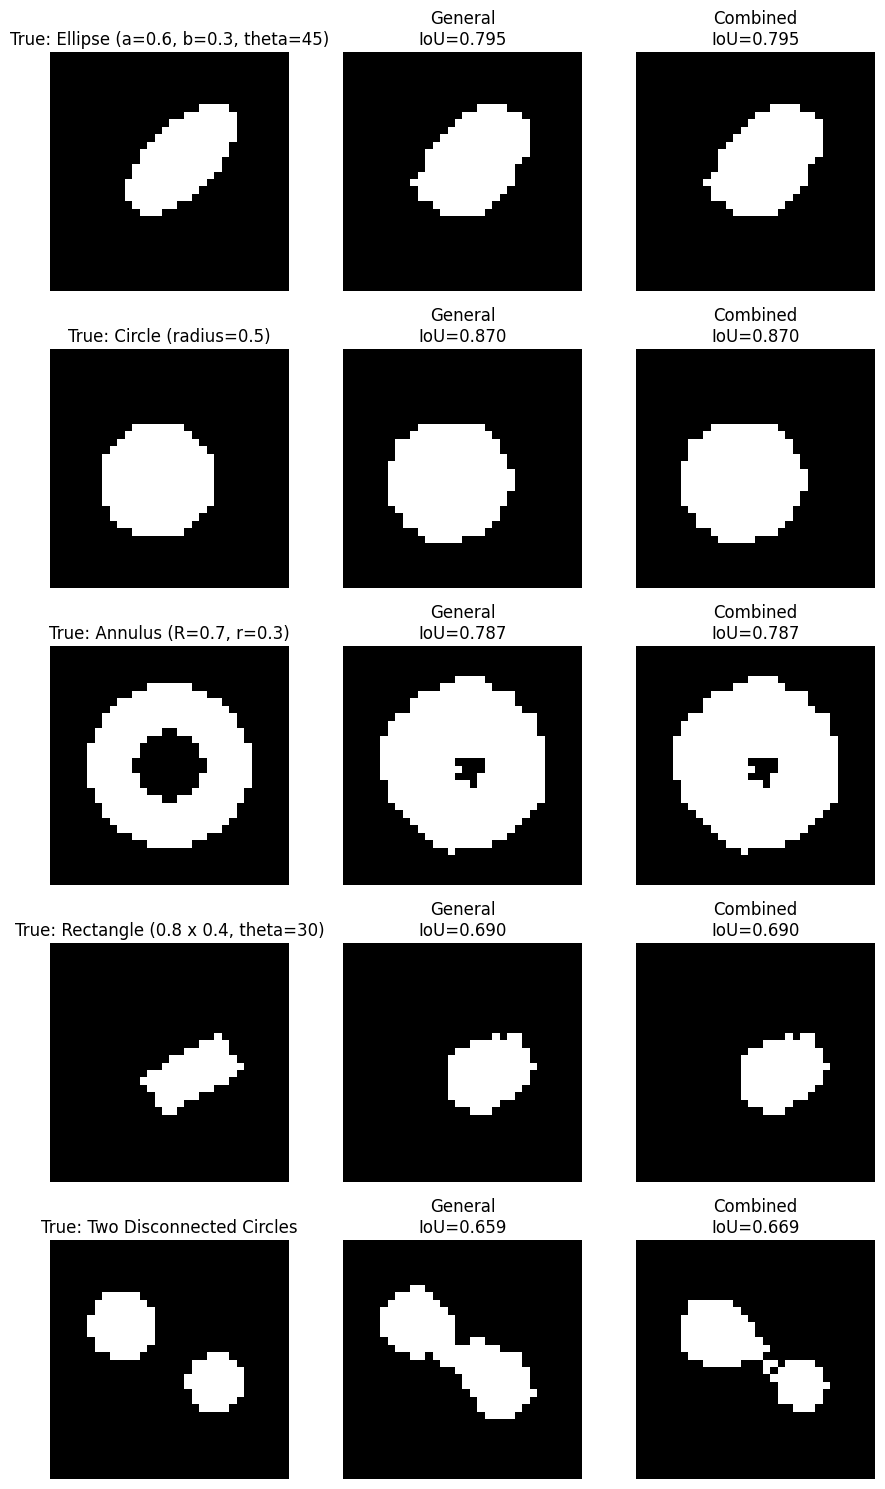

In [17]:
fig, axes = plt.subplots(len(general_dataset.fixed.names), 3, figsize=(9, 3 * len(general_dataset.fixed.names)))
for row_index, shape_name in enumerate(general_dataset.fixed.names):
    axes[row_index, 0].imshow(general_dataset.fixed.masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 0].set_title(f'True: {shape_name}')
    axes[row_index, 0].axis('off')

    axes[row_index, 1].imshow(general_fixed_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 1].set_title(f'General\nIoU={general_fixed_ious[row_index]:.3f}')
    axes[row_index, 1].axis('off')

    axes[row_index, 2].imshow(combined_fixed_binary_masks[row_index].reshape(run_config.grid_size, run_config.grid_size), cmap='gray', origin='lower')
    axes[row_index, 2].set_title(f'Combined\nIoU={combined_fixed_ious[row_index]:.3f}')
    axes[row_index, 2].axis('off')
plt.tight_layout()
plt.show()

## Shape-Type Breakdown

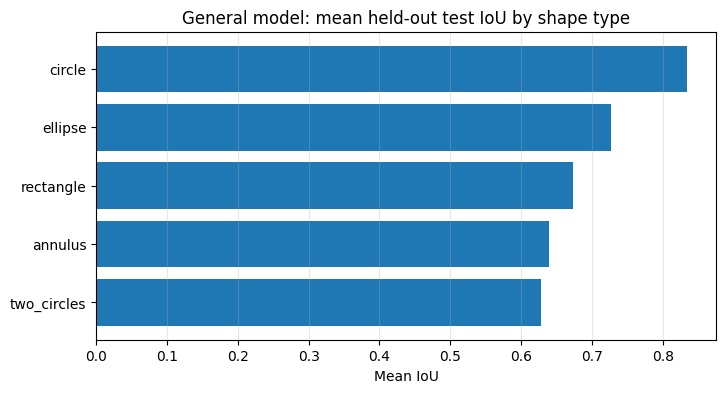

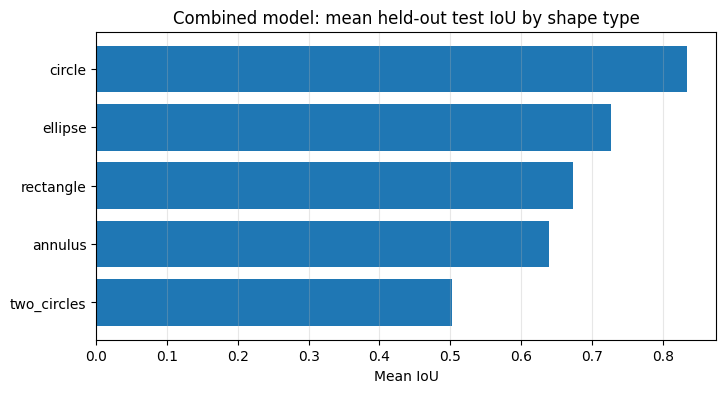

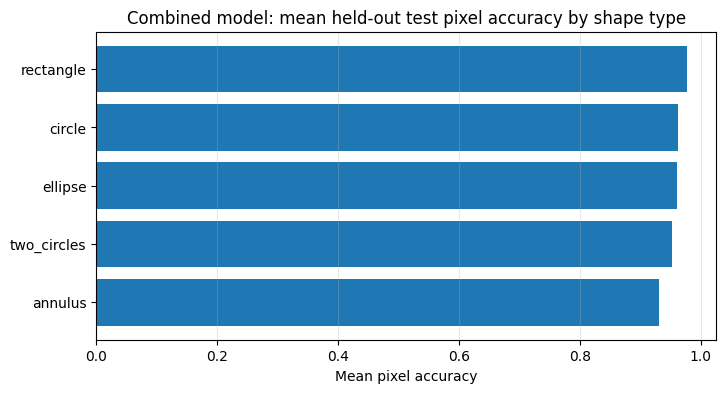

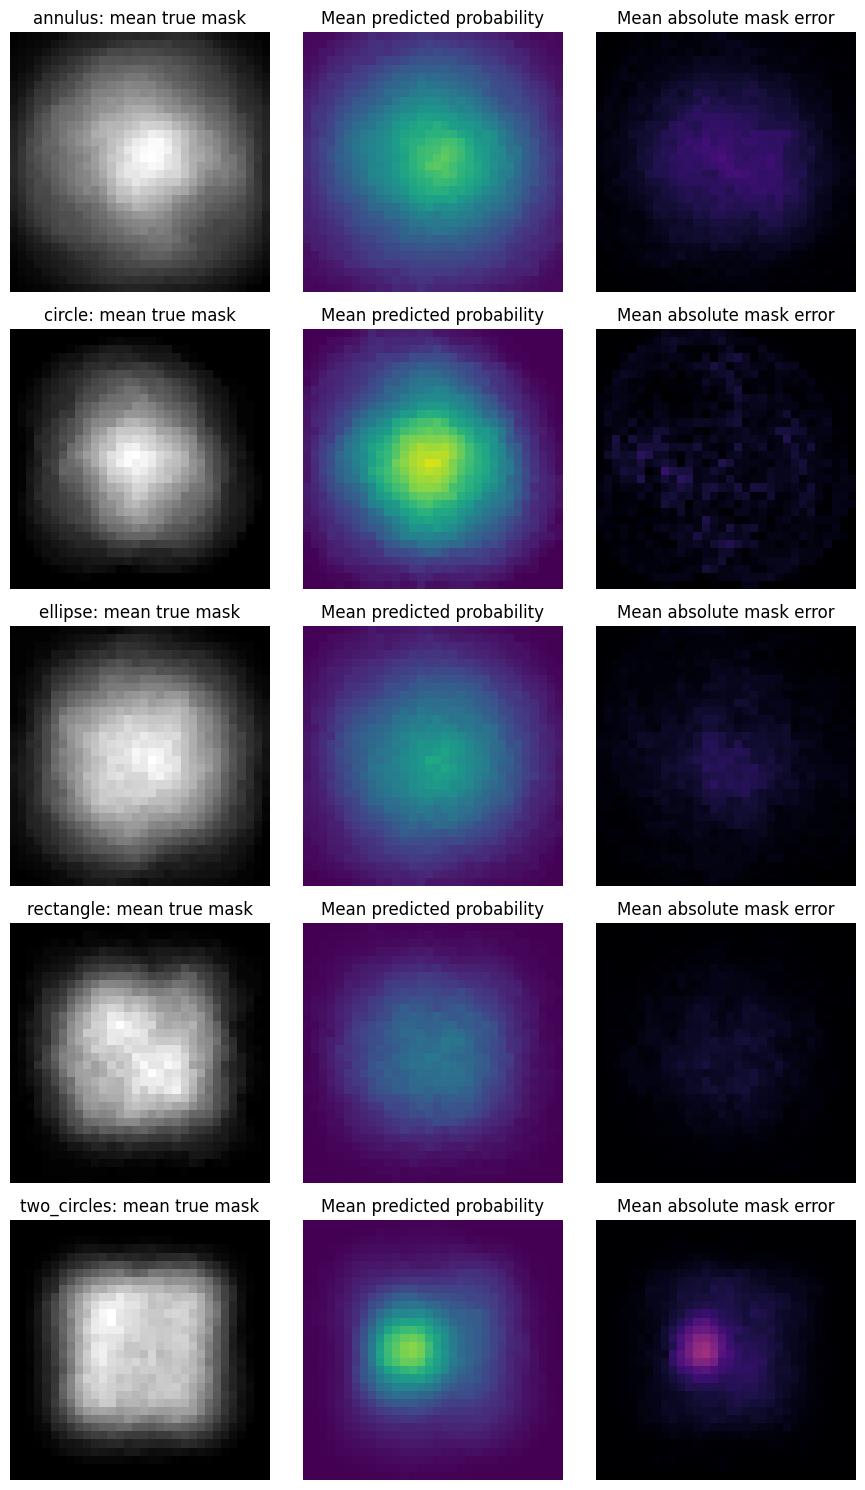

In [18]:
plot_shape_type_breakdown(general_dataset.test.shape_types, general_test_ious, 'General model: mean held-out test IoU by shape type', 'Mean IoU')
plot_shape_type_breakdown(general_dataset.test.shape_types, combined_test_ious, 'Combined model: mean held-out test IoU by shape type', 'Mean IoU')
plot_shape_type_breakdown(general_dataset.test.shape_types, compute_sample_pixel_accuracy(general_dataset.test.masks, combined_test_logits, selected_threshold), 'Combined model: mean held-out test pixel accuracy by shape type', 'Mean pixel accuracy')
show_average_maps_by_shape_type(general_dataset.test.shape_types, general_dataset.test.masks, combined_test_logits, run_config.grid_size, selected_threshold)

## Threshold Sweep

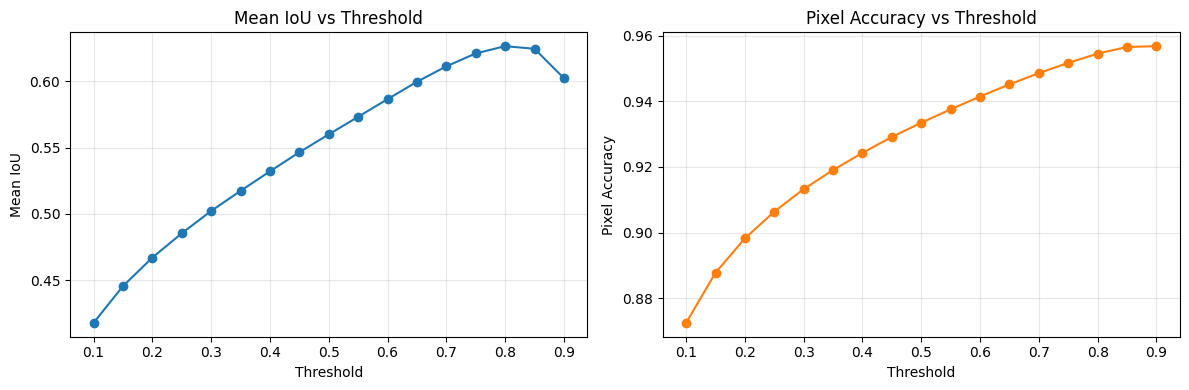

,threshold,mean_iou,pixel_accuracy
0,0.10,0.417861,0.872470
1,0.15,0.445536,0.887769
2,0.20,0.467048,0.898229
3,0.25,0.485336,0.906393
4,0.30,0.502215,0.913271
5,0.35,0.517321,0.919057
6,0.40,0.532072,0.924322
7,0.45,0.546443,0.929164
8,0.50,0.559904,0.933501
9,0.55,0.573183,0.937580


In [19]:
thresholds = np.linspace(0.1, 0.9, 17)
threshold_sweep = plot_threshold_sweep(general_dataset.test.masks, combined_test_logits, thresholds)
threshold_sweep

## Failure Analysis Table

In [20]:
test_coefficient_errors = np.abs(predicted_test_coefficients - general_dataset.test.coefficients).mean(axis=1)
failure_table = pd.DataFrame({
    'name': general_dataset.test.names,
    'shape_type': general_dataset.test.shape_types,
    'stage1_mean_abs_coeff_error': test_coefficient_errors,
    'general_iou': general_test_ious,
    'combined_iou': combined_test_ious,
    'specialist_gain': combined_test_ious - general_test_ious,
    'true_mask_area': general_dataset.test.masks.sum(axis=1),
    'predicted_mask_area_general': general_test_binary_masks.sum(axis=1),
    'predicted_mask_area_combined': combined_test_binary_masks.sum(axis=1),
})
failure_table.sort_values('combined_iou').head(10)

,name,shape_type,stage1_mean_abs_coeff_error,general_iou,combined_iou,specialist_gain,true_mask_area,predicted_mask_area_general,predicted_mask_area_combined
1,annulus,annulus,0.000931,0.000000,0.0,0.000000,62.0,78.0,78.0
950,two_circles,two_circles,0.000330,0.281250,0.0,-0.281250,19.0,22.0,0.0
969,annulus,annulus,0.000378,0.000000,0.0,0.000000,20.0,32.0,32.0
978,two_circles,two_circles,0.000324,0.129630,0.0,-0.129630,31.0,30.0,10.0
1481,annulus,annulus,0.000560,0.000000,0.0,0.000000,11.0,19.0,19.0
1366,two_circles,two_circles,0.000505,0.259740,0.0,-0.259740,38.0,59.0,35.0
1353,two_circles,two_circles,0.000284,0.617647,0.0,-0.617647,31.0,24.0,1.0
1332,annulus,annulus,0.000376,0.000000,0.0,0.000000,17.0,25.0,25.0
1323,two_circles,two_circles,0.000462,0.258065,0.0,-0.258065,31.0,47.0,41.0
1145,two_circles,two_circles,0.000282,0.301887,0.0,-0.301887,27.0,42.0,0.0


## Compact Summary Table

In [ ]:
summary_table = pd.DataFrame([
    {
        'label': 'general',
        'N': run_config.N,
        'stage1_test_mse': stage1_test_metrics['mse'],
        'stage1_fixed_mse': stage1_fixed_metrics['mse'],
        'test_mean_iou': general_test_metrics['mean_iou'],
        'fixed_mean_iou': general_fixed_metrics['mean_iou'],
        'parameter_count': count_parameters(general_head.model),
        'epochs_recorded': len(general_head.training_result.history['train_loss']),
    },
    {
        'label': 'combined',
        'N': run_config.N,
        'stage1_test_mse': stage1_test_metrics['mse'],
        'stage1_fixed_mse': stage1_fixed_metrics['mse'],
        'test_mean_iou': combined_test_metrics['mean_iou'],
        'fixed_mean_iou': combined_fixed_metrics['mean_iou'],
        'parameter_count': count_parameters(general_head.model) + (count_parameters(specialist_head.model) if specialist_head is not None else 0),
        'epochs_recorded': len(general_head.training_result.history['train_loss']) + (len(specialist_head.training_result.history['train_loss']) if specialist_head is not None else 0),
    },
])
summary_table

,label,N,stage1_test_mse,stage1_fixed_mse,test_mean_iou,fixed_mean_iou,parameter_count,epochs_recorded
0,general,10,0.000002,0.000001,0.666464,0.760100,4734464,44
1,combined,10,0.000002,0.000001,0.626402,0.762195,19445248,244


: 